<a href="https://colab.research.google.com/github/Bavesh-08/car-price-prediction/blob/main/car_price_predition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing the dependenmcies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
pf=pd.read_csv('/content/CarPrice_Assignment.csv')
pf.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
pf.shape

(205, 26)

In [ ]:
pf.describe()


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


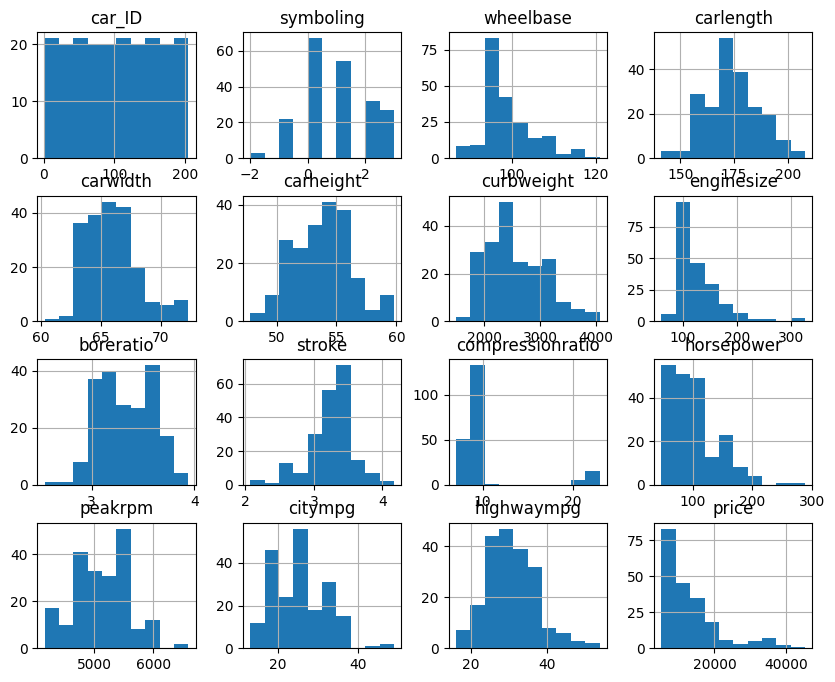

In [ ]:
#map for distrubutio of numeric features

pf.hist(figsize=(10,8))
plt.show()

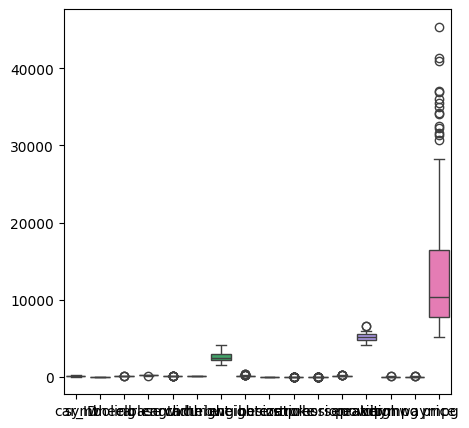

In [ ]:
#map for outliers
plt.figure(figsize=(5,5))
sns.boxplot(data=pf)
plt.show()

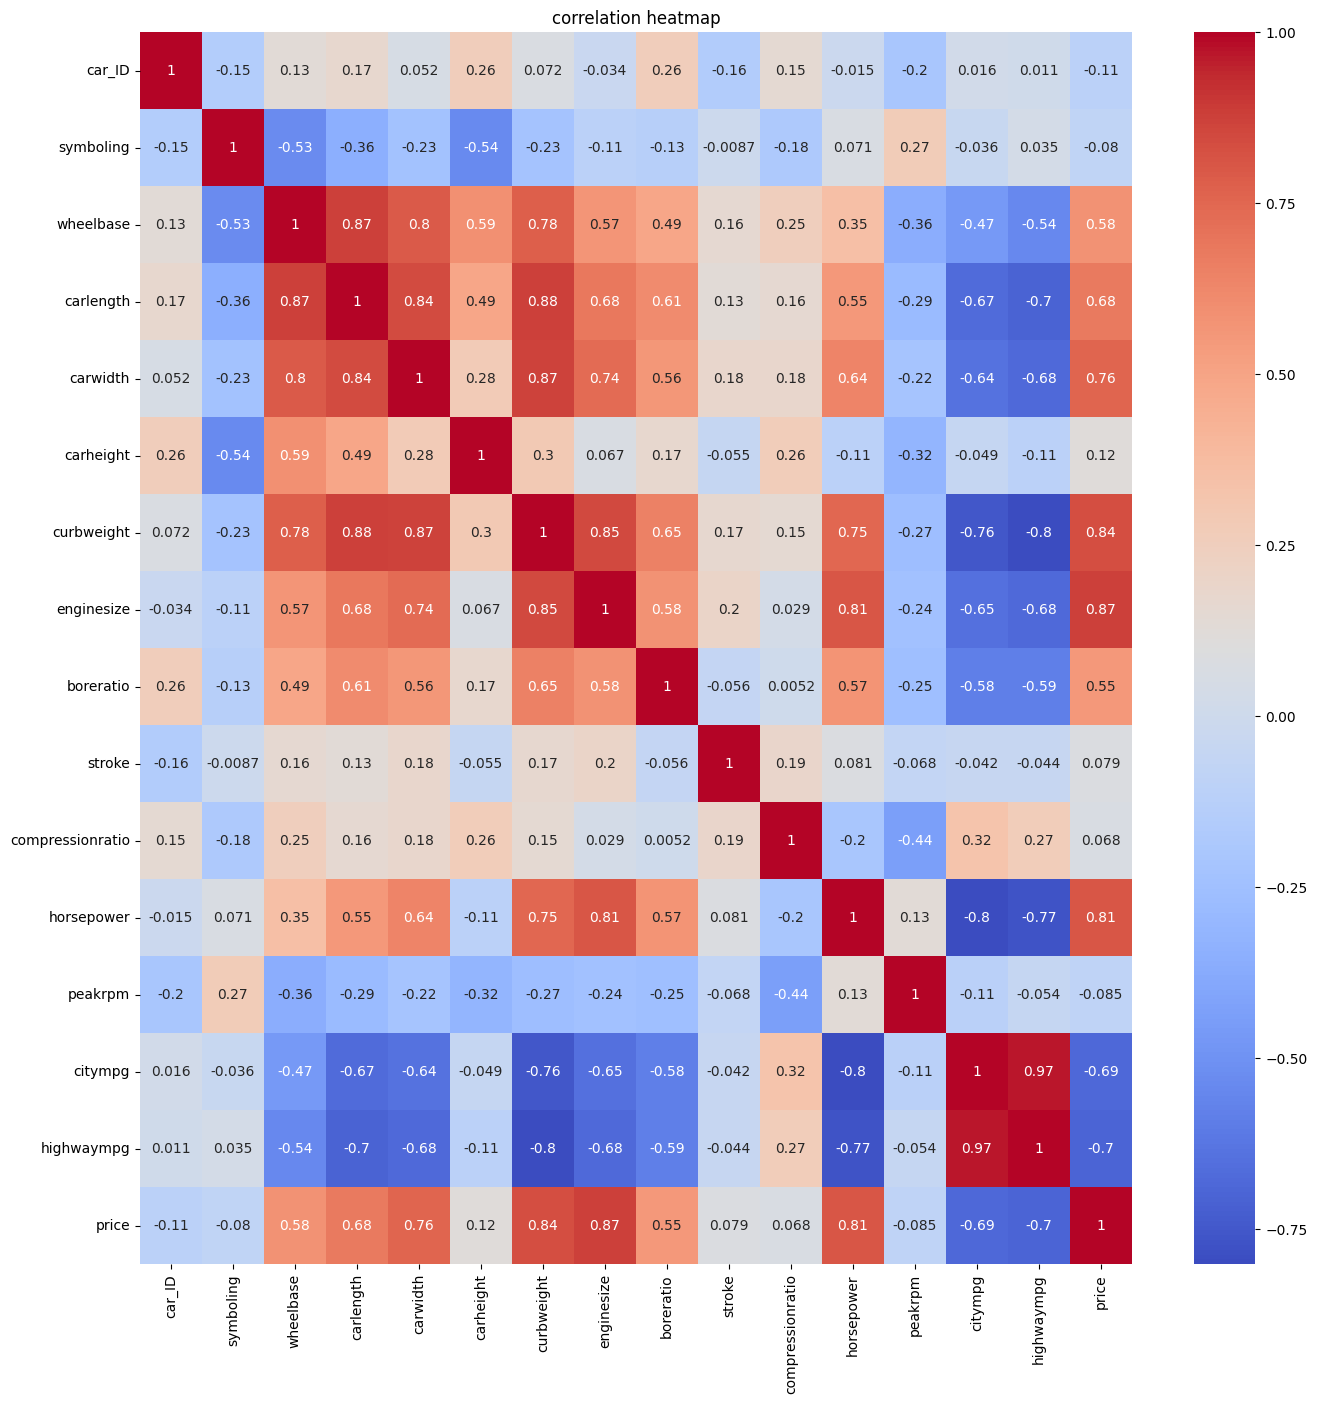

In [ ]:
plt.figure(figsize=(16,16))
sns.heatmap(pf.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [ ]:
label = LabelEncoder()
pf['CarName_encoded'] = label.fit_transform(pf.CarName)
pf['fueltype_encoded'] = label.fit_transform(pf.fueltype)
pf['aspiration_encoded'] = label.fit_transform(pf.aspiration)
pf['doornumber_encoded'] = label.fit_transform(pf.doornumber)
pf['drivewheel_encoded'] = label.fit_transform(pf.drivewheel)
pf['enginelocation_encoded'] = label.fit_transform(pf.enginelocation)
pf['enginetype_encoded'] = label.fit_transform(pf.enginetype)
pf['cylindernumber_encoded'] = label.fit_transform(pf.cylindernumber)
pf['fuelsystem_encoded'] = label.fit_transform(pf.fuelsystem)
pf['carbody_encoded'] = label.fit_transform(pf.carbody)

In [ ]:
pf.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [ ]:
pf.std(numeric_only=True)

,0
car_ID,59.322565
symboling,1.245307
wheelbase,6.021776
carlength,12.337289
carwidth,2.145204
carheight,2.443522
curbweight,520.680204
enginesize,41.642693
boreratio,0.270844
stroke,0.313597


In [ ]:
x = pf.drop(['CarName', 'fueltype', 'aspiration', 'doornumber', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'carbody', 'price'], axis=1)
y = pf['price']

In [ ]:
scaler=StandardScaler()
scaler.fit(x)
x_scaled=scaler.transform(x)

In [ ]:
x_scaled.std()

np.float64(1.0)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.1,random_state=2)

In [ ]:
print(x_train)
print(y)

[[-0.96320069 -0.67147172 -0.70859588 ... -0.14747536 -1.12217929
   0.44967732]
 [-1.62223274  0.133509    1.17252073 ... -1.40716068  0.8695675
   0.44967732]
 [-1.52084319 -0.67147172  0.40675645 ...  1.11220997  0.8695675
   0.44967732]
 ...
 [-0.50694773  1.74347043 -0.35900784 ... -2.66684601  0.8695675
  -3.05097525]
 [-1.47014842 -0.67147172  0.78963859 ...  1.11220997  0.8695675
   0.44967732]
 [ 1.11528501  0.93848971 -0.05936094 ... -0.14747536  0.8695675
  -1.88409106]]
0      13495.0
1      16500.0
2      16500.0
3      13950.0
4      17450.0
        ...   
200    16845.0
201    19045.0
202    21485.0
203    22470.0
204    22625.0
Name: price, Length: 205, dtype: float64


In [ ]:
#loding the models

lin_reg_model=LinearRegression()
lass_reg_model=Lasso()
random_forest_model=RandomForestRegressor()

lin_reg_model.fit(x_train,y_train)
lass_reg_model.fit(x_train,y_train)
random_forest_model.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
#predition to traning data

train_pred_1=lin_reg_model.predict(x_train)
train_pred_2=lass_reg_model.predict(x_train)
train_pred_3=random_forest_model.predict(x_train)

In [ ]:
#evulating error for traning data

error_score_1=metrics.r2_score(y_train,train_pred_1)
error_score_2=metrics.r2_score(y_train,train_pred_2)
error_score_3=metrics.r2_score(y_train,train_pred_3)

#pring the error value traning data

print("error in linear regression",error_score_1)
print("error in lasso regression",error_score_2)
print("error in random forest regression",error_score_3)

error in linear regression 0.8978224515245737
error in lasso regression 0.8978184888050147
error in random forest regression 0.989955167284897


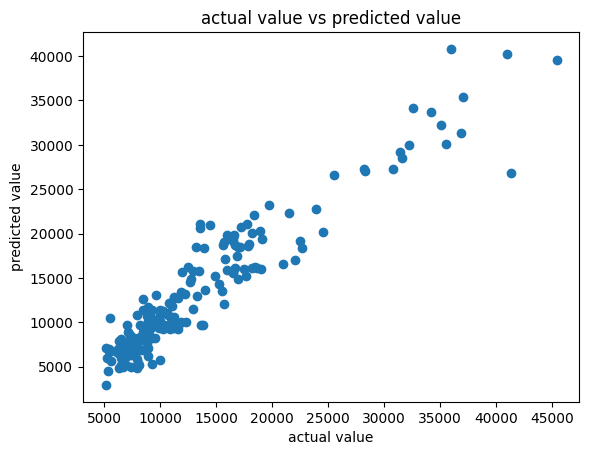

In [ ]:
#ploting the actualvalue and predicted value for linear regression

plt.scatter(y_train,train_pred_1)
plt.xlabel("actual value")
plt.ylabel("predicted value")
plt.title("actual value vs predicted value")
plt.show()

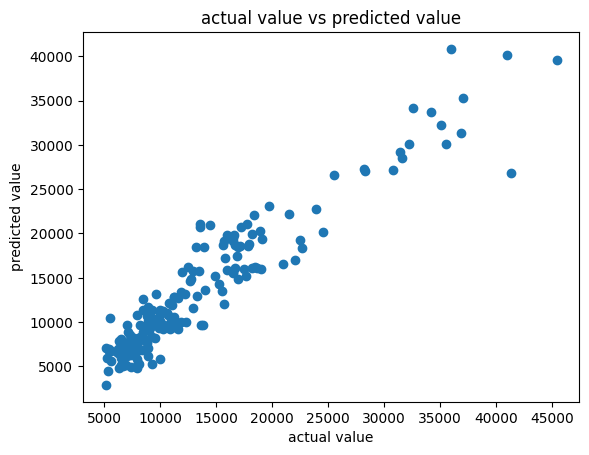

In [ ]:
#ploting the actualvalue and predicted value for lasso regression

plt.scatter(y_train,train_pred_2)
plt.xlabel("actual value")
plt.ylabel("predicted value")
plt.title("actual value vs predicted value")
plt.show()

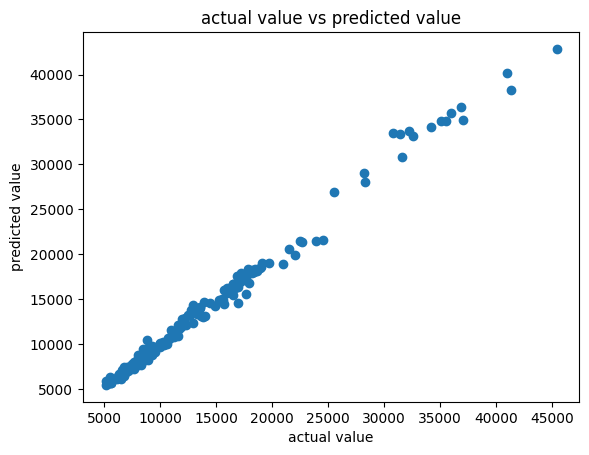

In [ ]:
#ploting the actualvalue and predicted value for random forest regression

plt.scatter(y_train,train_pred_3)
plt.xlabel("actual value")
plt.ylabel("predicted value")
plt.title("actual value vs predicted value")
plt.show()

In [ ]:
#prediction on test data

test_pred_1=lin_reg_model.predict(x_test)
test_pred_2=lass_reg_model.predict(x_test)
test_pred_3=random_forest_model.predict(x_test)

In [ ]:
#evulating error for test data

error_score_1_1=metrics.r2_score(y_test,test_pred_1)
error_score_2_2=metrics.r2_score(y_test,test_pred_2)
error_score_3_3=metrics.r2_score(y_test,test_pred_3)

#pring the error value for test data

print("error in linear regression",error_score_1_1)
print("error in lasso regression",error_score_2_2)
print("error in random forest regression",error_score_3_3)

error in linear regression 0.9011523406368519
error in lasso regression 0.9010531388078764
error in random forest regression 0.9036502216756432


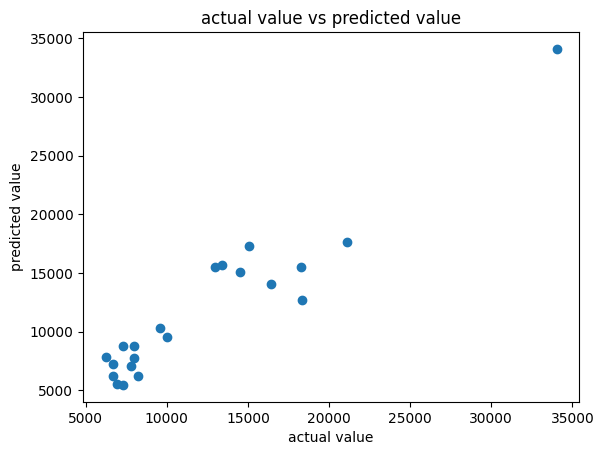

In [ ]:
#ploting the actualvalue and predicted value for linear regression

plt.scatter(y_test,test_pred_1)
plt.xlabel("actual value")
plt.ylabel("predicted value")
plt.title("actual value vs predicted value")
plt.show()

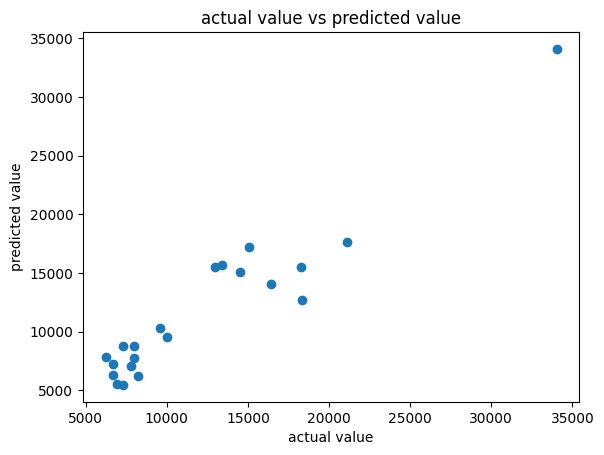

In [ ]:
#ploting the actualvalue and predicted value for lasso regression

plt.scatter(y_test,test_pred_2)
plt.xlabel("actual value")
plt.ylabel("predicted value")
plt.title("actual value vs predicted value")
plt.show()

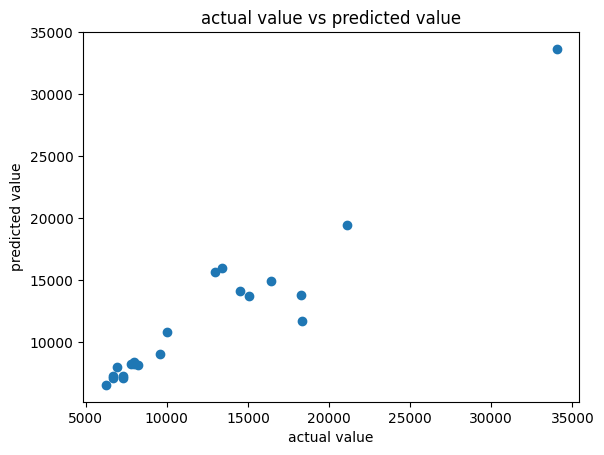

In [ ]:
#ploting the actualvalue and predicted value for random forest regression

plt.scatter(y_test,test_pred_3)
plt.xlabel("actual value")
plt.ylabel("predicted value")
plt.title("actual value vs predicted value")
plt.show()
